In [27]:
from pathlib import Path
import pandas as pd
import json
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

In [4]:
replay_dir = Path("/Users/marznewman/erdoswork/pokemon/data/replays/gen9-randombattle")

In [30]:
rows = []

for file in replay_dir.glob("*.json"):

    with open(file) as f:
        replay = json.load(f)

    battle_id = replay["id"]

    p1_name = replay["players"][0]
    p2_name = replay["players"][1]

    winner_name = None

    p1_lead = None
    p2_lead = None

    p1_switches = -1  # ignore lead switch
    p2_switches = -1

    p1_switched_early = 0
    p2_switched_early = 0

    p1_seen_move = False
    p2_seen_move = False

    turns = 0

    for line in replay["log"].split("\n"):

        if line.startswith("|turn|"):
            turns = int(line.split("|")[2])

        fields = line.split("|")

        if len(fields) < 2:
            continue

        if line.startswith("|win|"):
            winner_name = fields[2]

        # Record leads
        if line.startswith("|switch|"):

            slot = fields[2]
            pokemon = fields[3].split(",")[0]

            if p1_lead is None and slot.startswith("p1"):
                p1_lead = pokemon

            elif p2_lead is None and slot.startswith("p2"):
                p2_lead = pokemon

            else:
                if slot.startswith("p1"):
                    p1_switches += 1

                elif slot.startswith("p2"):
                    p2_switches += 1

        # Detect first move by each player
        if line.startswith("|move|"):

            slot = fields[2]

            if slot.startswith("p1"):
                p1_seen_move = True

            elif slot.startswith("p2"):
                p2_seen_move = True

        # Did they switch before ever moving?
        if line.startswith("|switch|"):

            slot = fields[2]

            if slot.startswith("p1") and not p1_seen_move and p1_switches > 0:
                p1_switched_early = 1

            elif slot.startswith("p2") and not p2_seen_move and p2_switches > 0:
                p2_switched_early = 1
    if turns > 0:
        p1_switch_rate = p1_switches / turns
        p2_switch_rate = p2_switches / turns
    else:
        p1_switch_rate = None
        p2_switch_rate = None
    switch_rate_diff = (p1_switch_rate - p2_switch_rate)

    winner = 1 if winner_name == p1_name else 0

    rows.append({
        "battle_id": battle_id,
        "winner": winner,
        "turns": turns,

        "p1_lead": p1_lead,
        "p2_lead": p2_lead,

        "p1_switched_early": p1_switched_early,
        "p2_switched_early": p2_switched_early,

        "p1_switches": p1_switches,
        "p2_switches": p2_switches,

        "p1_switch_rate": p1_switch_rate,
        "p2_switch_rate": p2_switch_rate,

        "switch_diff": p1_switches - p2_switches,
        "switch_rate_diff": switch_rate_diff
    })

switch_df = pd.DataFrame(rows)
print(len(switch_df))

4798


In [31]:
print("Probability that Player 1 wins if Player 1 switches early")
switch_df.groupby("p1_switched_early")["winner"].mean()

Probability that Player 1 wins if Player 1 switches early


p1_switched_early
0    0.483268
1    0.377551
Name: winner, dtype: float64

If Player 1 did switch before moving (p1_switched_early = 1), Player 1 has a smaller probability of winning

In [32]:
print("Probability that Player 1 wins if Player 2 switches early")
switch_df.groupby("p2_switched_early")["winner"].mean()

Probability that Player 1 wins if Player 2 switches early


p2_switched_early
0    0.471591
1    0.630631
Name: winner, dtype: float64

If Player 2 did switch before moving (p2_switched_early = 1), Player 1 has a higher probability of winning

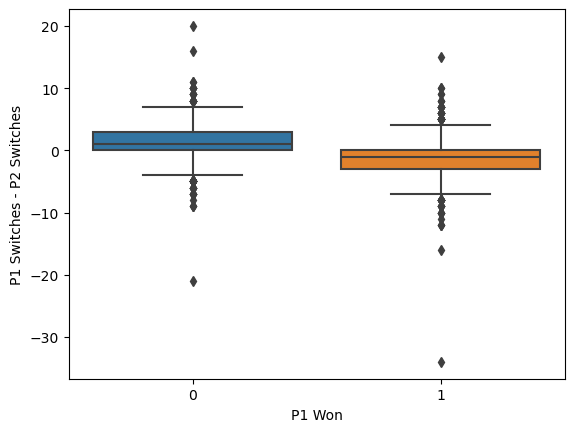

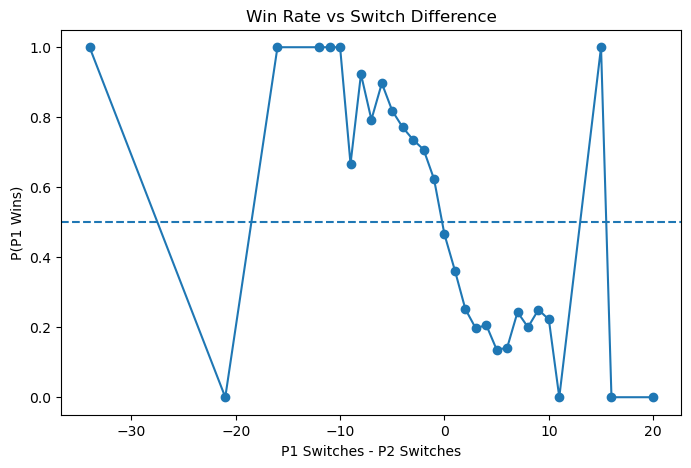

In [33]:
sns.boxplot(
    data=switch_df,
    x="winner",
    y="switch_diff"
)

plt.xlabel("P1 Won")
plt.ylabel("P1 Switches - P2 Switches")
plt.show()

winrate = (
    switch_df
    .groupby("switch_diff")["winner"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,5))

plt.plot(
    winrate["switch_diff"],
    winrate["winner"],
    marker="o"
)

plt.axhline(0.5, linestyle="--")

plt.xlabel("P1 Switches - P2 Switches")
plt.ylabel("P(P1 Wins)")
plt.title("Win Rate vs Switch Difference")
plt.show()

In [34]:
# How common is early switching?
print(f'Player 1 switched early: {switch_df["p1_switched_early"].value_counts()}')
print(f'\nPlayer 2 switched early: {switch_df["p2_switched_early"].value_counts()}')

Player 1 switched early: p1_switched_early
0    4602
1     196
Name: count, dtype: int64

Player 2 switched early: p2_switched_early
0    4576
1     222
Name: count, dtype: int64


In [35]:
table = pd.crosstab(
    switch_df["p1_switched_early"],
    switch_df["winner"]
)

chi2, p, dof, expected = chi2_contingency(table)

# If p value is <0.05, the relationship is not likely random
print(p)

0.0046757491791255025


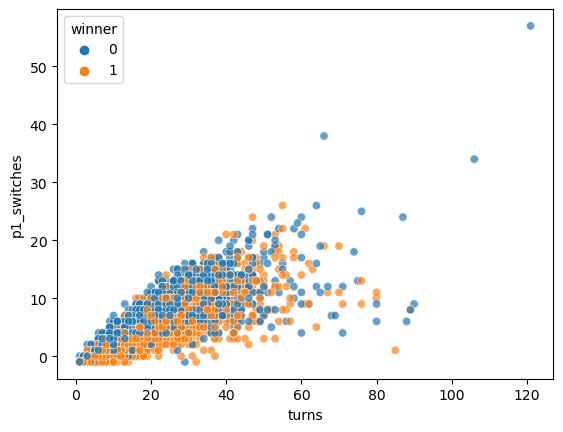

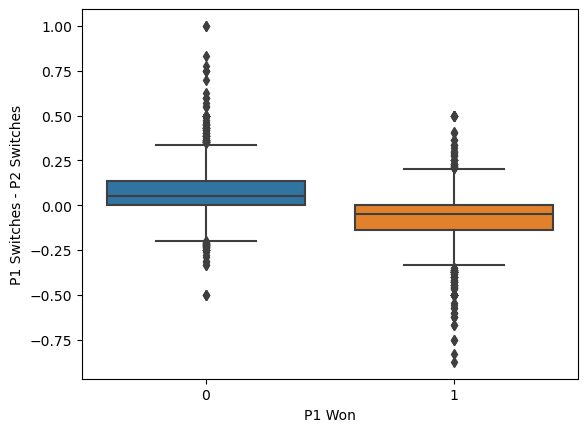

/var/folders/t3/c0ztmjln40s87sclht7wr1xr0000gn/T/ipykernel_71909/447118176.py:33: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rate_bin")["winner"]
/var/folders/t3/c0ztmjln40s87sclht7wr1xr0000gn/T/ipykernel_71909/447118176.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("rate_bin")


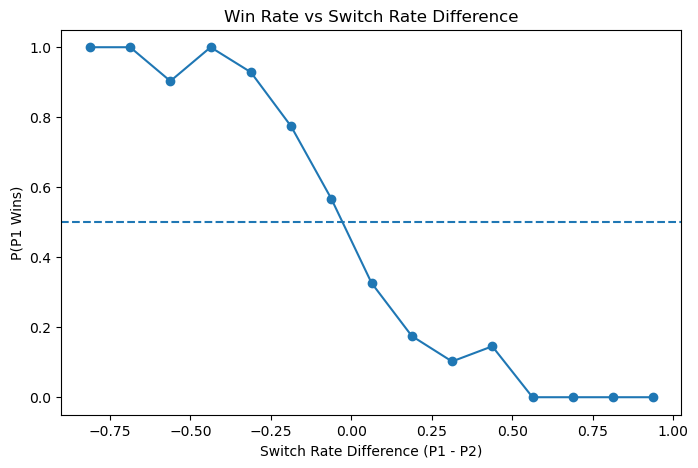

In [54]:
# More turns means more switching
plt.figure()
sns.scatterplot(
    data=switch_df,
    x="turns",
    y="p1_switches",
    hue="winner", 
    alpha=0.7
)
plt.show()

switch_df["turns"].corr(switch_df["p1_switches"])


###########
sns.boxplot(
    data=switch_df,
    x="winner",
    y="switch_rate_diff"
)

plt.xlabel("P1 Won")
plt.ylabel("P1 Switches - P2 Switches")
plt.show()

switch_df["rate_bin"] = pd.cut(
    switch_df["switch_rate_diff"],
    bins=15
)

winrate = (
    switch_df
    .groupby("rate_bin")["winner"]
    .mean()
    .reset_index()
)

counts = (
    switch_df
    .groupby("rate_bin")
    .size()
)

xvals = [
    interval.mid
    for interval in winrate["rate_bin"]
]

plt.figure(figsize=(8,5))

plt.plot(
    xvals,
    winrate["winner"],
    marker="o"
)

plt.axhline(0.5, linestyle="--")

plt.xlabel("Switch Rate Difference (P1 - P2)")
plt.ylabel("P(P1 Wins)")
plt.title("Win Rate vs Switch Rate Difference")

plt.show()